# PANGA EDA → xarray NetCDF (header-aware)

This notebook:
- Reads PANGA files downloaded from:https://panga.org/pub/data/incoming/panga_nam20_20260117.tar.gz
- combine components
- Filters to stations with **>5 years** of data within **2010 → present**
- Builds a **provider-specific NetCDF** (UNR) compatible with xarray

Constraints:
- Displacements and sigmas in **meters**
- Station metadata limited to **lat, lon, alt_m**


In [1]:
from __future__ import annotations

from pathlib import Path
import re
from datetime import datetime
import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pandas.core.dtypes.common import pandas_dtype

plt.rcParams["figure.dpi"] = 140


## 1) Inputs

Set these paths to your local folders.

In [2]:
DATA_DIR = Path("./data/panga_cleaned/")  # directory containing *.lat/*.lon/*.rad

assert DATA_DIR.exists(), f"Missing {DATA_DIR.resolve()}"
print("OK:", DATA_DIR)


OK: data\panga_cleaned


## 2) read panga files

In [9]:
COMPONENT_MAP = {
    "lon": ("east_m", "east_sigma_m"),
    "lat": ("north_m", "north_sigma_m"),
    "rad": ("up_m", "up_sigma_m"),
}


def _find_component_data_start_line(path: Path) -> int:
    """Return the 0-based line index where numeric data begins."""
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for i, raw in enumerate(f):
            line = raw.strip()
            if not line or line.startswith("#"):
                continue
            if re.match(r"^[\s\-\+\deE\.]+$", line):
                return i

    raise ValueError(f"Could not determine data start line in {path}")


def decimal_year_to_datetime(dec_year: pd.Series) -> pd.Series:
    """
    Convert decimal year values to daily timestamps.

    The decimal year encodes elapsed fraction of the calendar year.
    Because the source files store decimal years with limited precision,
    convert the fraction to an integer day offset explicitly.

    Returns timezone-naive datetime64[ns] values fixed at midnight.
    """
    dec = pd.to_numeric(dec_year, errors="coerce")

    out = pd.Series(pd.NaT, index=dec.index, dtype="datetime64[ns]")

    valid = dec.notna()
    if not valid.any():
        return out

    dec_valid = dec.loc[valid].astype(float)

    years = np.floor(dec_valid).astype(int)
    frac = dec_valid - years

    year_length_days = np.where(
        pd.Series(years, index=dec_valid.index).map(calendar.isleap),
        366,
        365,
    )

    # Convert fractional year to nearest integer day offset.
    # This avoids timestamps like 2010-01-02 00:00:08.639996950.
    day_offset = np.rint(frac.to_numpy(dtype=np.float64) * year_length_days).astype(int)

    # Guard against values that round to exactly Jan 1 of the next year
    # for dec_year values very close to YYYY+1.
    start = pd.to_datetime(years.astype(str), format="%Y")
    time = start + pd.to_timedelta(day_offset, unit="D")

    out.loc[valid] = time.to_numpy(dtype="datetime64[ns]")
    return out


def read_panga_component_file(path: Path, value_col: str, sigma_col: str) -> pd.DataFrame:
    """Read one component file like 'ALBH.lat'."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    station_id = path.stem.lower()
    start = _find_component_data_start_line(path)

    df = pd.read_csv(
        path,
        sep=r"\s+",
        engine="python",
        skiprows=start,
        comment="#",
        header=None,
        names=["dec_year", value_col, sigma_col],
    )

    for c in ["dec_year", value_col, sigma_col]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["station"] = station_id
    df["time"] = decimal_year_to_datetime(df["dec_year"])

    return df.dropna(subset=["time", value_col]).reset_index(drop=True)


def read_panga_series_station(base_dir: Path, station_id: str) -> pd.DataFrame:
    """Read and combine '{station}.lat/.lon/.rad' files for one station."""
    base_dir = Path(base_dir)
    station_id = str(station_id).strip().lower()

    merged = None

    for suffix, (value_col, sigma_col) in COMPONENT_MAP.items():
        path = base_dir / f"{station_id}.{suffix}"
        comp = read_panga_component_file(
            path,
            value_col=value_col,
            sigma_col=sigma_col,
        )

        cols = ["station", "time", "dec_year", value_col, sigma_col]

        if merged is None:
            merged = comp[cols]
        else:
            merged = merged.merge(
                comp[cols],
                on=["station", "time"],
                how="outer",
                suffixes=("", f"_{suffix}"),
            )

    # Keep one representative dec_year column.
    dec_year_cols = [c for c in merged.columns if c.startswith("dec_year")]
    merged["dec_year"] = merged[dec_year_cols].bfill(axis=1).iloc[:, 0]
    merged = merged.drop(columns=[c for c in dec_year_cols if c != "dec_year"])

    merged = (
        merged
        .dropna(subset=["time", "east_m", "north_m", "up_m"])
        .sort_values(["time"])
        .reset_index(drop=True)
    )

    return merged[
        [
            "station",
            "time",
            "dec_year",
            "east_m",
            "north_m",
            "up_m",
            "east_sigma_m",
            "north_sigma_m",
            "up_sigma_m",
        ]
    ]


## 4) Inspect one station

In [10]:
stat = "ALBH"

raw = read_panga_series_station(DATA_DIR, stat)
raw.head(25)


,station,time,dec_year,east_m,north_m,up_m,east_sigma_m,north_sigma_m,up_sigma_m
0,albh,1996-01-02,1996.00273,2.30916,2.87550,-2.54742,2.02168,1.65389,6.03899
1,albh,1996-01-03,1996.00546,1.41039,1.57188,-2.44970,2.00906,1.65389,6.03899
2,albh,1996-01-04,1996.00820,1.44002,0.75810,3.77194,2.02890,1.65082,6.05439
3,albh,1996-01-05,1996.01093,2.54206,1.90717,5.63647,1.99284,1.63240,5.93475
4,albh,1996-01-06,1996.01366,2.67948,0.46308,-0.60316,1.98382,1.62217,5.89092
5,albh,1996-01-07,1996.01639,-0.03672,0.55883,0.95002,2.01447,1.63957,6.04729
6,albh,1996-01-08,1996.01913,0.07146,-1.51856,2.95797,2.09380,1.67334,6.31027
7,albh,1996-01-09,1996.02186,3.22701,-0.90911,7.97467,2.07577,1.65492,6.15628
8,albh,1996-01-10,1996.02459,-0.17709,3.18020,-0.30793,2.07397,1.72656,6.13969
9,albh,1996-01-11,1996.02732,0.54917,3.48937,-2.68786,2.00546,1.63650,5.97029


#### verification plot

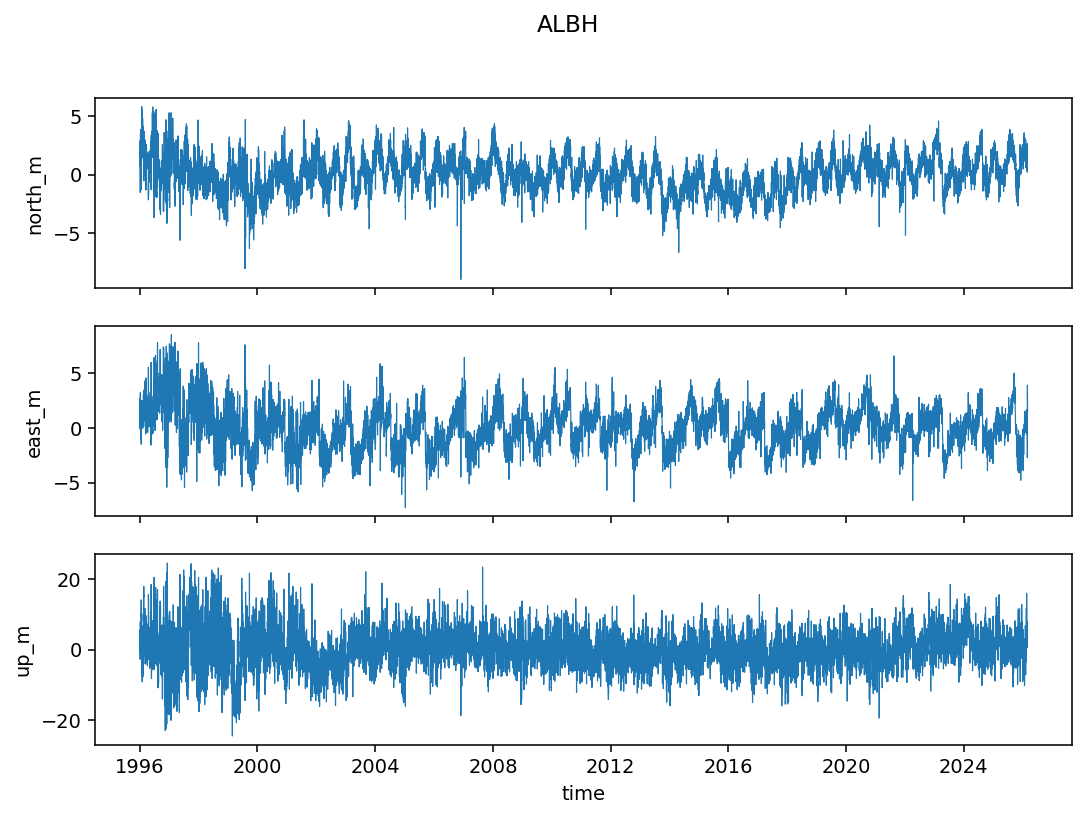

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

ax[0].plot(raw.time, raw.north_m, lw=0.6)
ax[0].set_ylabel("north_m")

ax[1].plot(raw.time, raw.east_m, lw=0.6)
ax[1].set_ylabel("east_m")

ax[2].plot(raw.time, raw.up_m, lw=0.6)
ax[2].set_ylabel("up_m")
ax[2].set_xlabel("time")

plt.suptitle(stat)
plt.show()


## 5) Apply filters: 2010→present and >5 years

In [12]:
station_list = pd.read_csv("./resources/catalog_subset_bbox.csv")
station_list

,name,lat,lon,elev_m
0,ABBY,49.072141,-122.197803,195.280394
1,ABOT,49.029436,-122.266570,-4.009165
2,AGNS,42.552765,-124.059114,51.368366
3,AL2H,48.389780,-123.487472,31.750396
4,ALB4,48.389740,-123.487687,30.890637
...,...,...,...,...
599,YCS2,46.941249,-122.590563,91.426696
600,YELM,46.948717,-122.605735,81.993392
601,YOCR,45.379102,-121.743553,1884.269527
602,YONC,43.634111,-123.298301,86.491947


In [13]:
START_YEAR = 2010.0
END_YEAR = 2025 + 1
MIN_YEARS = 5.0


def filter_window(ts: pd.DataFrame) -> pd.DataFrame:
    return ts[(ts.dec_year >= START_YEAR) & (ts.dec_year <= END_YEAR)].copy()


def has_min_span(ts: pd.DataFrame, min_years: float = MIN_YEARS) -> bool:
    if ts.empty:
        return False
    return float(ts.dec_year.max() - ts.dec_year.min()) >= float(min_years)


ts_by_station = {}
fail = []  # (station, filename, error)
missing_on_disk = []  # stations listed in CSV but file not found

for st in station_list.name.astype(str).str.strip().str.lower().tolist():
    required_files = [DATA_DIR / f"{st}.{suffix}" for suffix in COMPONENT_MAP]
    if not all(p.exists() for p in required_files):
        missing_on_disk.append(st)
        continue
    try:
        ts = read_panga_series_station(DATA_DIR, st)
        ts = filter_window(ts)

        if has_min_span(ts):
            ts_by_station[st] = ts
        else:
            fail.append((st, ", ".join(p.name for p in required_files), f"Span < {MIN_YEARS}y after filtering"))
    except Exception as e:
        fail.append((st, ", ".join(p.name for p in required_files), str(e)))

valid_stations = sorted(ts_by_station.keys())
print(f"Valid stations loaded: {len(valid_stations)}")
print(f"Missing on disk: {len(missing_on_disk)}")
print(f"Failed (parse/filter/span): {len(fail)}")


Valid stations loaded: 373
Missing on disk: 177
Failed (parse/filter/span): 54


In [14]:
if missing_on_disk:
    print("\n--- Missing on disk (first 50) ---")
    for s in missing_on_disk[:50]:
        print(" ", s)

if fail:
    print("\n--- Failed (first 20) ---")
    for st, fname, err in fail[:20]:
        print(f" {st} ({fname}): {err}")



--- Missing on disk (first 50) ---
  abby
  abot
  al2h
  alb4
  aldr
  bcab
  bcbu
  bcch
  bcco
  bccq
  bccr
  bccy
  bcdn
  bcdt
  bcho
  bclg
  bcnn
  bcpm
  bcsc
  bcsk
  bcsq
  bcts
  bcut
  bcvi
  bcvt
  bcws
  blnp
  c046
  ca1r
  cacc
  cach
  cacr
  cacy
  caeu
  cafl
  cafm
  cams
  cawi
  cayk
  cbrv
  ccrt
  chco
  chw2
  cmbr
  cme6
  cobi
  copm
  coqu
  cot3
  cou2

--- Failed (first 20) ---
 agns (agns.lon, agns.lat, agns.rad): Span < 5.0y after filtering
 blvu (blvu.lon, blvu.lat, blvu.rad): Span < 5.0y after filtering
 brnb (brnb.lon, brnb.lat, brnb.rad): Span < 5.0y after filtering
 bton (bton.lon, bton.lat, bton.rad): Span < 5.0y after filtering
 cami (cami.lon, cami.lat, cami.rad): Span < 5.0y after filtering
 cedr (cedr.lon, cedr.lat, cedr.rad): Span < 5.0y after filtering
 chst (chst.lon, chst.lat, chst.rad): Span < 5.0y after filtering
 coan (coan.lon, coan.lat, coan.rad): Span < 5.0y after filtering
 crbn (crbn.lon, crbn.lat, crbn.rad): Span < 5.0y after fil

In [15]:
SIG10_TOL = 1e-6  # exact 10.0 usually, but tolerance costs nothing

def _is_sigma10_row(row: pd.Series, tol: float = SIG10_TOL) -> bool:
    sig = np.array(
        [row.get("east_sigma_m"), row.get("north_sigma_m"), row.get("up_sigma_m")],
        dtype=float,
    )
    return np.all(np.isfinite(sig)) and np.all(np.abs(sig - 10.0) <= tol)

def enforce_unique_time_sigma10_exception(df: pd.DataFrame, station: str) -> pd.DataFrame:
    """
    Policy:
      - If no duplicate 'time': return df sorted by time.
      - If exactly one duplicated day with exactly 2 rows:
          - drop the one row whose sigmas are (10,10,10) and continue
          - else raise
      - If more complicated duplicates: raise
    """
    if "time" not in df.columns:
        raise ValueError(f"{station}: missing 'time' column")

    df = df.sort_values("time").reset_index(drop=True)

    dup_mask = df["time"].duplicated(keep=False)
    if not dup_mask.any():
        return df

    dup_df = df.loc[dup_mask].copy()
    dup_times = dup_df["time"].unique()

    n_dup_times = len(dup_times)
    n_dup_rows = len(dup_df)

    # allow only the simplest case: one duplicate time, two rows
    if not (n_dup_times == 1 and n_dup_rows == 2):
        raise ValueError(
            f"{station}: duplicate 'time' too complex "
            f"(dup_times={n_dup_times}, dup_rows={n_dup_rows})"
        )

    idxs = dup_df.index.to_list()
    r0 = df.loc[idxs[0]]
    r1 = df.loc[idxs[1]]

    r0_bad = _is_sigma10_row(r0)
    r1_bad = _is_sigma10_row(r1)

    if r0_bad ^ r1_bad:
        bad_idx = idxs[0] if r0_bad else idxs[1]
        day = pd.Timestamp(dup_times[0]).strftime("%Y-%m-%d")
        print(f"{station}: dropping sigma==10 row on {day}")
        df = df.drop(index=bad_idx).reset_index(drop=True)

        # hard post-condition
        if df["time"].duplicated().any():
            raise ValueError(f"{station}: still has duplicate 'time' after sigma10 drop")

        return df

    day = pd.Timestamp(dup_times[0]).strftime("%Y-%m-%d")
    raise ValueError(
        f"{station}: duplicated day {day} but sigma10 exception not applicable "
        f"(row0_sigma10={r0_bad}, row1_sigma10={r1_bad})"
    )

## 6) xarray Dataset with dims (time, station) and station coords from catalog


In [16]:
list_ds = []
fail = []

for st, tmp_df in ts_by_station.items():
    try:
        df = tmp_df.copy()

        # Enforce cleanup rule before indexing
        df = enforce_unique_time_sigma10_exception(df, station=st)

        if "station" in df.columns:
            df = df.drop(columns=["station"])

        # Validate/standardize time.
        # At this point, time should already be daily midnight timestamps
        # from decimal_year_to_datetime().
        df["time"] = pd.to_datetime(df["time"], errors="raise")

        # If timezone-aware, make timezone-naive
        if getattr(df["time"].dt, "tz", None) is not None:
            df["time"] = df["time"].dt.tz_convert(None)

        # Defensive: force exact daily midnight timestamps
        df["time"] = df["time"].dt.normalize()

        # Now duplicates are true duplicate station-days, not decimal-year offset artifacts.
        # Keep this as a hard failure unless you intentionally want to aggregate/drop them.
        if df["time"].duplicated().any():
            dup_times = (
                df.loc[df["time"].duplicated(keep=False), "time"]
                .sort_values()
                .unique()
            )
            raise ValueError(
                f"Duplicate daily timestamps for station {st}: "
                f"{dup_times[:5]}{'...' if len(dup_times) > 5 else ''}"
            )

        # Build time index
        df = df.set_index("time").sort_index()

        # Convert to xarray and add station dimension
        ds_st = df.to_xarray().expand_dims(station=[st])

        list_ds.append(ds_st)

    except Exception as e:
        fail.append((st, str(e)))

if not list_ds:
    print(f"No stations successfully converted. Failed stations: {len(fail)}")
    for st, err in fail[:20]:
        print(" ", st, "->", err)
    raise ValueError("No station datasets were created; inspect fail above.")

ds = xr.concat(list_ds, dim="station", join="outer").sortby("time")

print(f"Stations concatenated: {ds.sizes['station']}")
print(f"Time steps (union):    {ds.sizes['time']}")

if fail:
    print(f"Failed stations:       {len(fail)} (first 10 below)")
    for st, err in fail[:10]:
        print(" ", st, "->", err)

ds

Stations concatenated: 373
Time steps (union):    5845


<xarray.Dataset> Size: 122MB
Dimensions:        (station: 373, time: 5845)
Coordinates:
  * station        (station) object 3kB 'albh' 'arli' 'asbu' ... 'yonc' 'zse1'
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2026-01-01
Data variables:
    dec_year       (station, time) float64 17MB 2.01e+03 2.01e+03 ... 2.026e+03
    east_m         (station, time) float64 17MB -0.06938 2.286 ... -1.241 -2.144
    north_m        (station, time) float64 17MB 1.668 2.3 1.962 ... 2.829 2.089
    up_m           (station, time) float64 17MB -2.769 4.657 ... -8.864 1.295
    east_sigma_m   (station, time) float64 17MB 1.768 1.771 ... 1.357 1.364
    north_sigma_m  (station, time) float64 17MB 1.465 1.473 ... 1.572 1.579
    up_sigma_m     (station, time) float64 17MB 5.353 5.355 ... 4.927 5.004

## 7) Station coords from catalog (CSV)

In [17]:
station_list["station"] = station_list["name"].astype(str).str.strip().str.lower()
station_list = station_list.set_index("station")

station_list_aligned = station_list.reindex(ds.station.to_numpy())

ds = ds.assign_coords(
    lat=("station", station_list_aligned["lat"].to_numpy(dtype=np.float64)),
    lon=("station", station_list_aligned["lon"].to_numpy(dtype=np.float64)),
    elev_m=("station", station_list_aligned["elev_m"].to_numpy(dtype=np.float64)),
)
ds

<xarray.Dataset> Size: 122MB
Dimensions:        (station: 373, time: 5845)
Coordinates:
  * station        (station) object 3kB 'albh' 'arli' 'asbu' ... 'yonc' 'zse1'
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2026-01-01
    lat            (station) float64 3kB 48.39 48.17 43.82 ... 45.38 43.63 47.29
    lon            (station) float64 3kB -123.5 -122.1 -121.4 ... -123.3 -122.2
    elev_m         (station) float64 3kB 31.77 23.29 1.509e+03 ... 86.49 82.06
Data variables:
    dec_year       (station, time) float64 17MB 2.01e+03 2.01e+03 ... 2.026e+03
    east_m         (station, time) float64 17MB -0.06938 2.286 ... -1.241 -2.144
    north_m        (station, time) float64 17MB 1.668 2.3 1.962 ... 2.829 2.089
    up_m           (station, time) float64 17MB -2.769 4.657 ... -8.864 1.295
    east_sigma_m   (station, time) float64 17MB 1.768 1.771 ... 1.357 1.364
    north_sigma_m  (station, time) float64 17MB 1.465 1.473 ... 1.572 1.579
    up_sigma_m     (station, time) float64 17MB 5.353 5.355 ... 4.927 5.004

## 8) Write NetCDF (PANGA)

In [18]:
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)
OUT_NC = OUT_DIR / "gnss_PANGA_2010_2025.nc"

encoding = {v: {"zlib": True, "complevel": 4} for v in ds.data_vars}
ds.to_netcdf(OUT_NC, encoding=encoding)
print("Wrote:", OUT_NC)


Wrote: outputs\gnss_PANGA_2010_2025.nc


## 9) Smoke test: reopen and plot one station

<xarray.Dataset> Size: 122MB
Dimensions:        (station: 373, time: 5845)
Coordinates:
  * station        (station) <U4 6kB 'albh' 'arli' 'asbu' ... 'yonc' 'zse1'
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2026-01-01
    lat            (station) float64 3kB ...
    lon            (station) float64 3kB ...
    elev_m         (station) float64 3kB ...
Data variables:
    dec_year       (station, time) float64 17MB ...
    east_m         (station, time) float64 17MB ...
    north_m        (station, time) float64 17MB ...
    up_m           (station, time) float64 17MB ...
    east_sigma_m   (station, time) float64 17MB ...
    north_sigma_m  (station, time) float64 17MB ...
    up_sigma_m     (station, time) float64 17MB ...


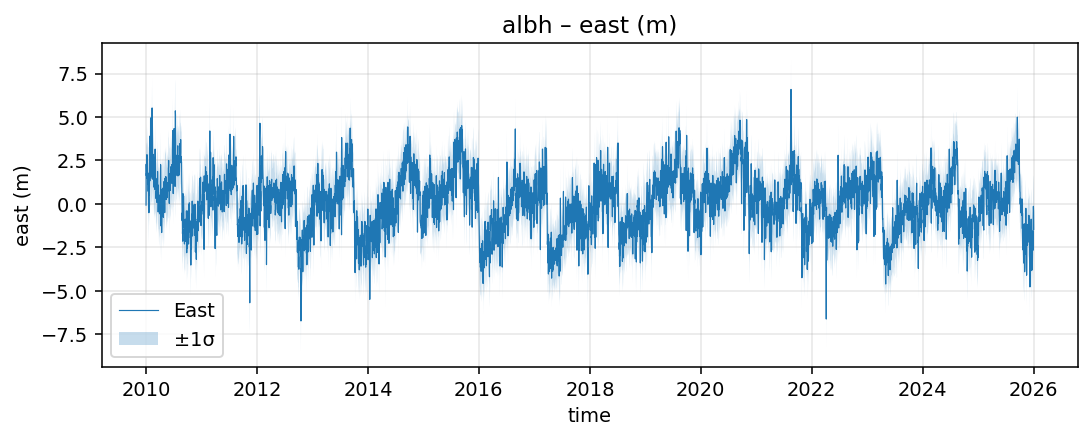

In [19]:
ds = xr.open_dataset(OUT_NC)
print(ds)

st = "albh"
sel = ds.sel(station=st).dropna(dim="time", how="all")

plt.figure(figsize=(9, 3))

# central value
plt.plot(sel.time, sel.east_m, lw=0.6, label="East")

# ±1σ envelope
plt.fill_between(
    sel.time,
    sel.east_m - sel.east_sigma_m,
    sel.east_m + sel.east_sigma_m,
    alpha=0.25,
    linewidth=0,
    label="±1σ"
)

plt.title(f"{st} – east (m)")
plt.xlabel("time")
plt.ylabel("east (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


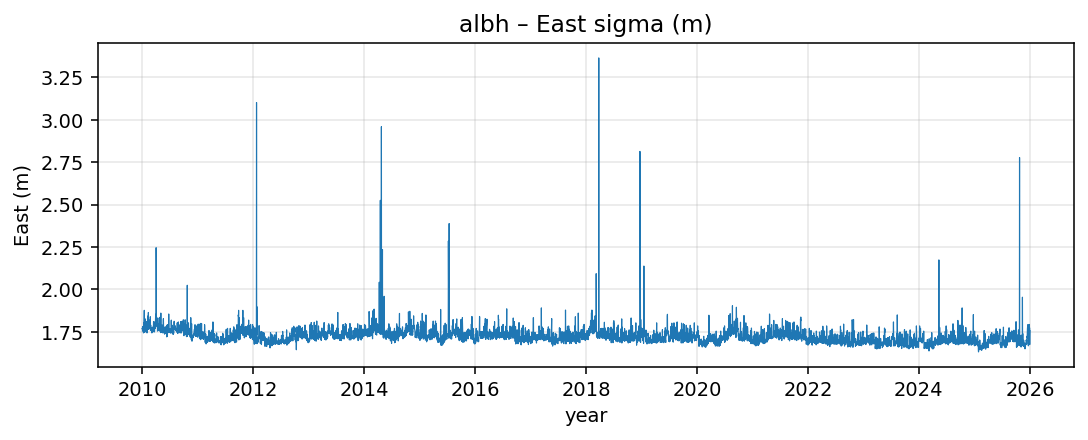

In [20]:
plt.figure(figsize=(9, 3))
plt.plot(sel.time, sel.east_sigma_m, lw=0.6)
plt.title(f"{st} – East sigma (m)")
plt.xlabel("year")
plt.ylabel("East (m)")
plt.grid(True, alpha=0.3)
plt.show()

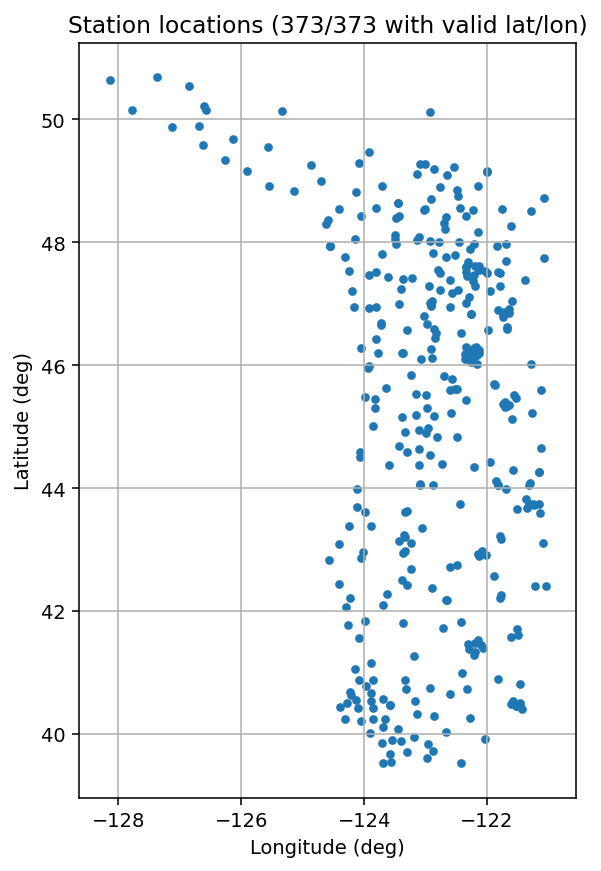

In [21]:
# --- grab station coords ---
lon = ds["lon"].values
lat = ds["lat"].values

mask = np.isfinite(lon) & np.isfinite(lat)
n_total = lon.size
n_ok = int(mask.sum())

# --- plot ---
plt.figure(figsize=(9, 7))
plt.scatter(lon[mask], lat[mask], s=12)  # (no explicit color per your style rule)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"Station locations ({n_ok}/{n_total} with valid lat/lon)")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")

# nice bounds with padding
if n_ok > 0:
    xmin, xmax = np.nanmin(lon[mask]), np.nanmax(lon[mask])
    ymin, ymax = np.nanmin(lat[mask]), np.nanmax(lat[mask])
    pad_x = max(0.5, 0.05 * (xmax - xmin))
    pad_y = max(0.5, 0.05 * (ymax - ymin))
    plt.xlim(xmin - pad_x, xmax + pad_x)
    plt.ylim(ymin - pad_y, ymax + pad_y)

plt.show()